In [2]:
import warnings
import logging
import transformers

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

In [3]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd
import numpy as np
import math

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate


import torch
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

In [17]:
llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    dtype=torch.float16,
    device_map="auto"
)

hf_pipeline = pipeline(
    "text-generation",
    model = model, 
    tokenizer = tokenizer,
    device="cuda",
    return_full_text = False,
    max_new_tokens=1,      
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)   

llm = HuggingFacePipeline(pipeline = hf_pipeline)

basic_template = """ 
Sklasyfikuj nastrój tekstu, przypisując go do jednej z trzech kategorii: Positive, Negative lub Neutral.
Odpowiedz tylko i wyłącznie jednym słowem z listy (Positive, Negative, Neutral). Nie dopisuj żadnego komentarza.

Tekst: {review}
Kategoria:"""

prompt = PromptTemplate.from_template(basic_template)

llm_chain = prompt | llm

reviews_texts = df['sentence'].tolist()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [18]:
preds = llm_chain.batch ([
    {"review": text} for text in reviews_texts
])

In [22]:
preds = [pred.strip() for pred in preds]

print(preds[0])
print(len(preds[0][1]))

Positive
1


              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
    Negative       0.98      0.30      0.46       300
     Neutral       0.43      0.64      0.51       117
    Positive       0.79      0.84      0.81       197
          __       0.00      0.00      0.00         0
        ____       0.00      0.00      0.00         0
    ________       0.00      0.00      0.00         0

    accuracy                           0.54       614
   macro avg       0.31      0.25      0.26       614
weighted avg       0.81      0.54      0.58       614



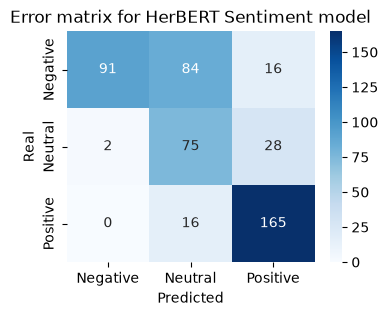

In [23]:
print(classification_report(df['target'], preds))

plt.figure(figsize=(4, 3))
cm = confusion_matrix(df['target'], preds, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.title('Error matrix for HerBERT Sentiment model')
plt.show()

print()
